# DBSCAN Parameter Tuning for German Cities

This notebook systematically tests different DBSCAN parameter combinations (eps_km and min_samples) to find the optimal configuration for clustering German cities. We'll compare results using multiple metrics and visualize trade-offs.

## 1. Import Required Libraries

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Add the project root to path for imports
project_root = Path('.').resolve().parent
sys.path.insert(0, str(project_root))

from core.spatial import (
    cluster_cities, 
    describe_clusters, 
    EARTH_RADIUS_KM
)

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Load and Prepare Data

In [2]:
from core.data import find_cities_file

cities_file = find_cities_file()
print(f"📍 Loading cities from: {cities_file}")

# Read raw data - file format: "City, latitude, longitude"
raw_data = []
with open(cities_file, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            parts = line.rsplit(',', 2)
            if len(parts) == 3:
                city_name = parts[0].strip()
                try:
                    latitude = float(parts[1].strip())
                    longitude = float(parts[2].strip())
                    raw_data.append({'city_name': city_name, 'latitude': latitude, 'longitude': longitude})
                except ValueError:
                    print(f"Warning: Could not parse {line}")

cities = pd.DataFrame(raw_data)

print(f"\n✓ Loaded {len(cities)} cities")
print(f"  Latitude range: [{cities['latitude'].min():.2f}, {cities['latitude'].max():.2f}]")
print(f"  Longitude range: [{cities['longitude'].min():.2f}, {cities['longitude'].max():.2f}]")

📍 Loading cities from: c:\Users\aksha\Downloads\Documents\FAU\project seminar\code\data\cities_de_50k.txt

✓ Loaded 236 cities
  Latitude range: [47.66, 54.79]
  Longitude range: [6.08, 14.99]


## 3. Parameter Grid Search

In [3]:
# Define parameter grid to test
eps_values = [30, 32, 35, 38, 40, 45]  # kilometers
min_samples_values = [2, 3, 4, 5]

print("🔧 Testing DBSCAN Parameter Combinations")
print(f"{'='*60}")
print(f"eps_km values to test: {eps_values}")
print(f"min_samples values to test: {min_samples_values}")
print(f"Total combinations: {len(eps_values) * len(min_samples_values)}")
print(f"{'='*60}\n")

# Prepare result storage
results = []

# Test all combinations
for eps_km in eps_values:
    for min_samples in min_samples_values:
        try:
            # Run DBSCAN
            labels = cluster_cities(cities, eps_km=eps_km, min_samples=min_samples)
            profile = describe_clusters(labels)
            
            # Calculate metrics
            n_clusters = profile.cluster_count
            n_noise = profile.noise_count
            coverage = (len(cities) - n_noise) / len(cities) * 100
            
            # Get cluster sizes for statistics
            cluster_sizes = list(profile.cluster_sizes.values())
            avg_cluster_size = np.mean(cluster_sizes) if cluster_sizes else 0
            max_cluster_size = np.max(cluster_sizes) if cluster_sizes else 0
            
            # Calculate silhouette score (only if clusters exist and not all noise)
            if n_clusters > 0 and n_noise < len(cities):
                # Get coordinates for silhouette score
                coords = cities[['latitude', 'longitude']].values
                silhouette = silhouette_score(coords, labels, metric='haversine', sample_size=min(1000, len(cities)))
                davies_bouldin = davies_bouldin_score(coords, labels)
            else:
                silhouette = np.nan
                davies_bouldin = np.nan
            
            # Store results
            results.append({
                'eps_km': eps_km,
                'min_samples': min_samples,
                'clusters': n_clusters,
                'noise': n_noise,
                'coverage': coverage,
                'avg_size': avg_cluster_size,
                'max_size': max_cluster_size,
                'silhouette': silhouette,
                'davies_bouldin': davies_bouldin
            })
            
            status = f"silhouette={silhouette:6.3f}" if not np.isnan(silhouette) else "silhouette=N/A"
            print(f"✓ eps={eps_km:2d}, min_samples={min_samples}: "
                  f"{n_clusters:2d} clusters, {n_noise:2d} noise, {coverage:5.1f}% coverage, {status}")
            
        except Exception as e:
            print(f"✗ eps={eps_km:2d}, min_samples={min_samples}: Error - {str(e)}")

# Create results DataFrame
results_df = pd.DataFrame(results)
print(f"\n✓ Grid search complete! Tested {len(results_df)} parameter combinations")

🔧 Testing DBSCAN Parameter Combinations
eps_km values to test: [30, 32, 35, 38, 40, 45]
min_samples values to test: [2, 3, 4, 5]
Total combinations: 24

✓ eps=30, min_samples=2: 21 clusters, 46 noise,  80.5% coverage, silhouette=-0.033
✓ eps=30, min_samples=3: 14 clusters, 60 noise,  74.6% coverage, silhouette=-0.041
✓ eps=30, min_samples=4:  9 clusters, 78 noise,  66.9% coverage, silhouette=-0.063
✓ eps=30, min_samples=5:  7 clusters, 89 noise,  62.3% coverage, silhouette= 0.037
✓ eps=32, min_samples=2: 21 clusters, 40 noise,  83.1% coverage, silhouette= 0.026
✓ eps=32, min_samples=3: 13 clusters, 56 noise,  76.3% coverage, silhouette= 0.028
✓ eps=32, min_samples=4: 10 clusters, 71 noise,  69.9% coverage, silhouette=-0.091
✓ eps=32, min_samples=5:  7 clusters, 88 noise,  62.7% coverage, silhouette= 0.044
✓ eps=35, min_samples=2: 19 clusters, 33 noise,  86.0% coverage, silhouette=-0.063
✓ eps=35, min_samples=3: 10 clusters, 51 noise,  78.4% coverage, silhouette=-0.020
✓ eps=35, min_sam

## 4. Results Summary Table

In [4]:
# Display results in formatted table
print("\n" + "="*120)
print("PARAMETER TUNING RESULTS")
print("="*120)
print(results_df.to_string(index=False))
print("="*120)

# Highlight best combinations
print("\n🎯 BEST PARAMETER COMBINATIONS BY METRIC:")
print(f"\n1. Maximum Coverage: {results_df.loc[results_df['coverage'].idxmax()].to_dict()}")
print(f"\n2. Maximum Silhouette Score (best cluster quality): {results_df.loc[results_df['silhouette'].idxmax()].to_dict()}")
print(f"\n3. Minimum Davies-Bouldin Index (lower is better): {results_df.loc[results_df['davies_bouldin'].idxmin()].to_dict()}")
print(f"\n4. Best Balance (high coverage + good silhouette):")
# Find balance between coverage and silhouette
valid_df = results_df.dropna(subset=['silhouette'])
valid_df['balance_score'] = valid_df['coverage'] * 0.7 + (valid_df['silhouette'] + 1) * 50 * 0.3
best_balance = valid_df.loc[valid_df['balance_score'].idxmax()]
print(f"   {best_balance.to_dict()}")


PARAMETER TUNING RESULTS
 eps_km  min_samples  clusters  noise  coverage  avg_size  max_size  silhouette  davies_bouldin
     30            2        21     46 80.508475  9.047619        71   -0.033129        1.676842
     30            3        14     60 74.576271 12.571429        71   -0.041467        1.704705
     30            4         9     78 66.949153 17.555556        71   -0.063457        1.447030
     30            5         7     89 62.288136 21.000000        71    0.036851        1.174293
     32            2        21     40 83.050847  9.333333        71    0.026057        1.999554
     32            3        13     56 76.271186 13.846154        71    0.028228        1.825011
     32            4        10     71 69.915254 16.500000        71   -0.090873        1.320320
     32            5         7     88 62.711864 21.142857        71    0.043645        1.168479
     35            2        19     33 86.016949 10.684211        79   -0.062805        1.513162
     35       

## 5. Heatmap Visualizations

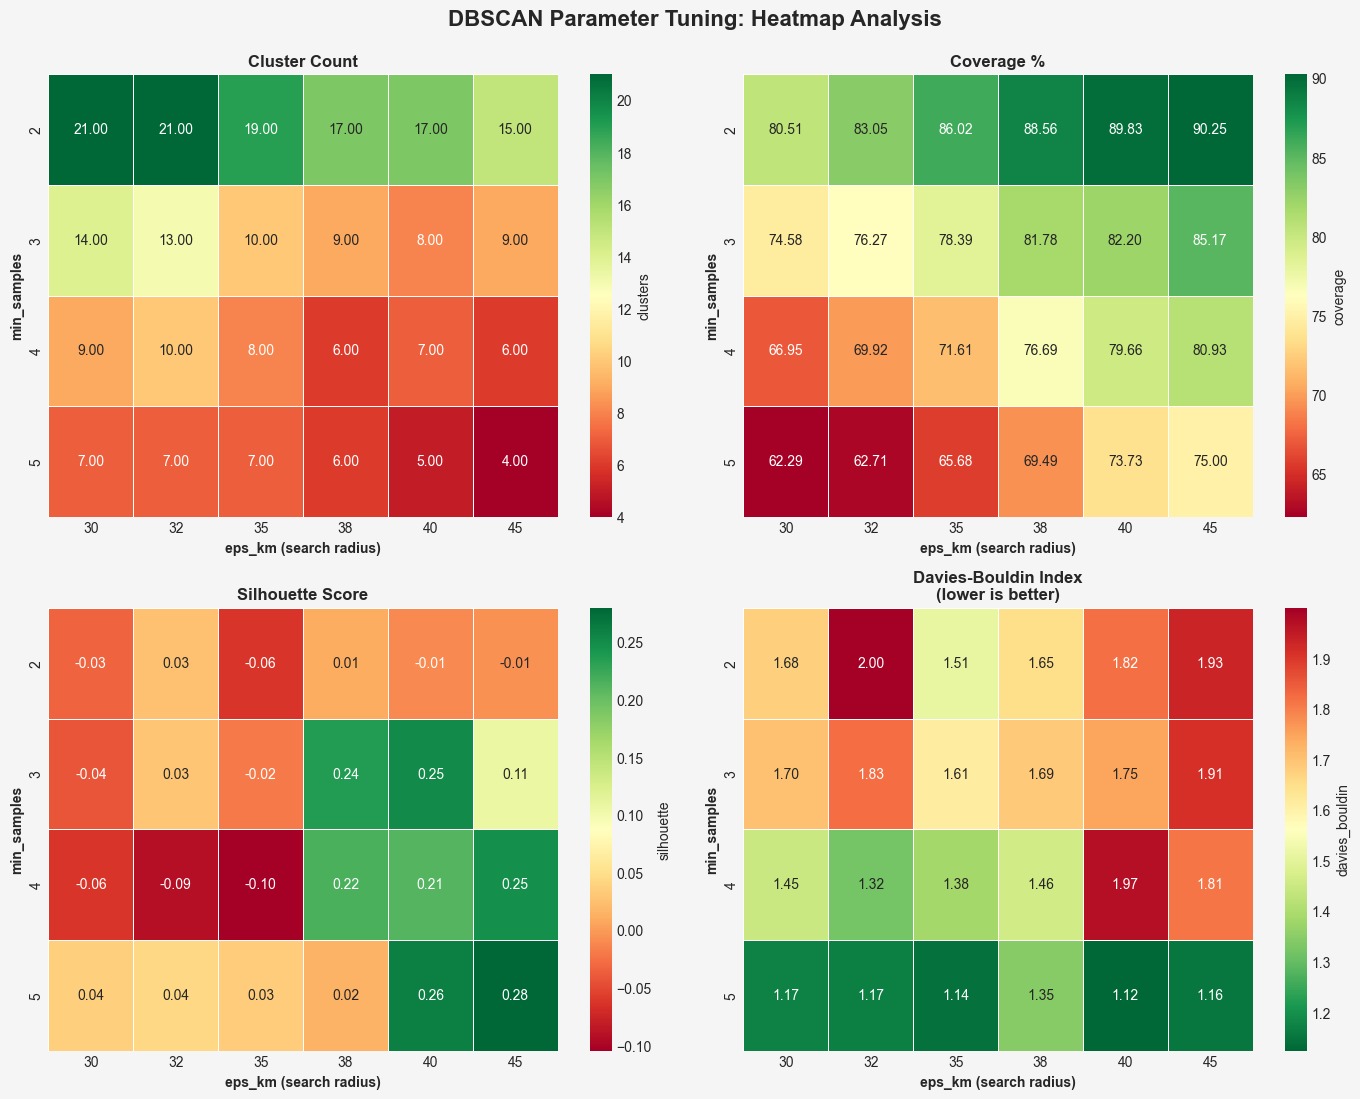

✓ Heatmap visualizations complete!


In [5]:
# Create heatmaps for key metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 11), facecolor="#f5f5f5")
fig.suptitle("DBSCAN Parameter Tuning: Heatmap Analysis", fontsize=16, fontweight="bold", y=0.995)

metrics = ['clusters', 'coverage', 'silhouette', 'davies_bouldin']
titles = ['Cluster Count', 'Coverage %', 'Silhouette Score', 'Davies-Bouldin Index\n(lower is better)']

for idx, (ax, metric, title) in enumerate(zip(axes.flat, metrics, titles)):
    # Create pivot table for heatmap
    pivot = results_df.pivot(index='min_samples', columns='eps_km', values=metric)
    
    # Create heatmap
    cmap_choice = 'RdYlGn' if metric != 'davies_bouldin' else 'RdYlGn_r'
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap=cmap_choice,
                ax=ax, cbar_kws={'label': metric}, linewidths=0.5)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('eps_km (search radius)', fontweight='bold')
    ax.set_ylabel('min_samples', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Heatmap visualizations complete!")

## 6. Trend Analysis: How Parameters Affect Results

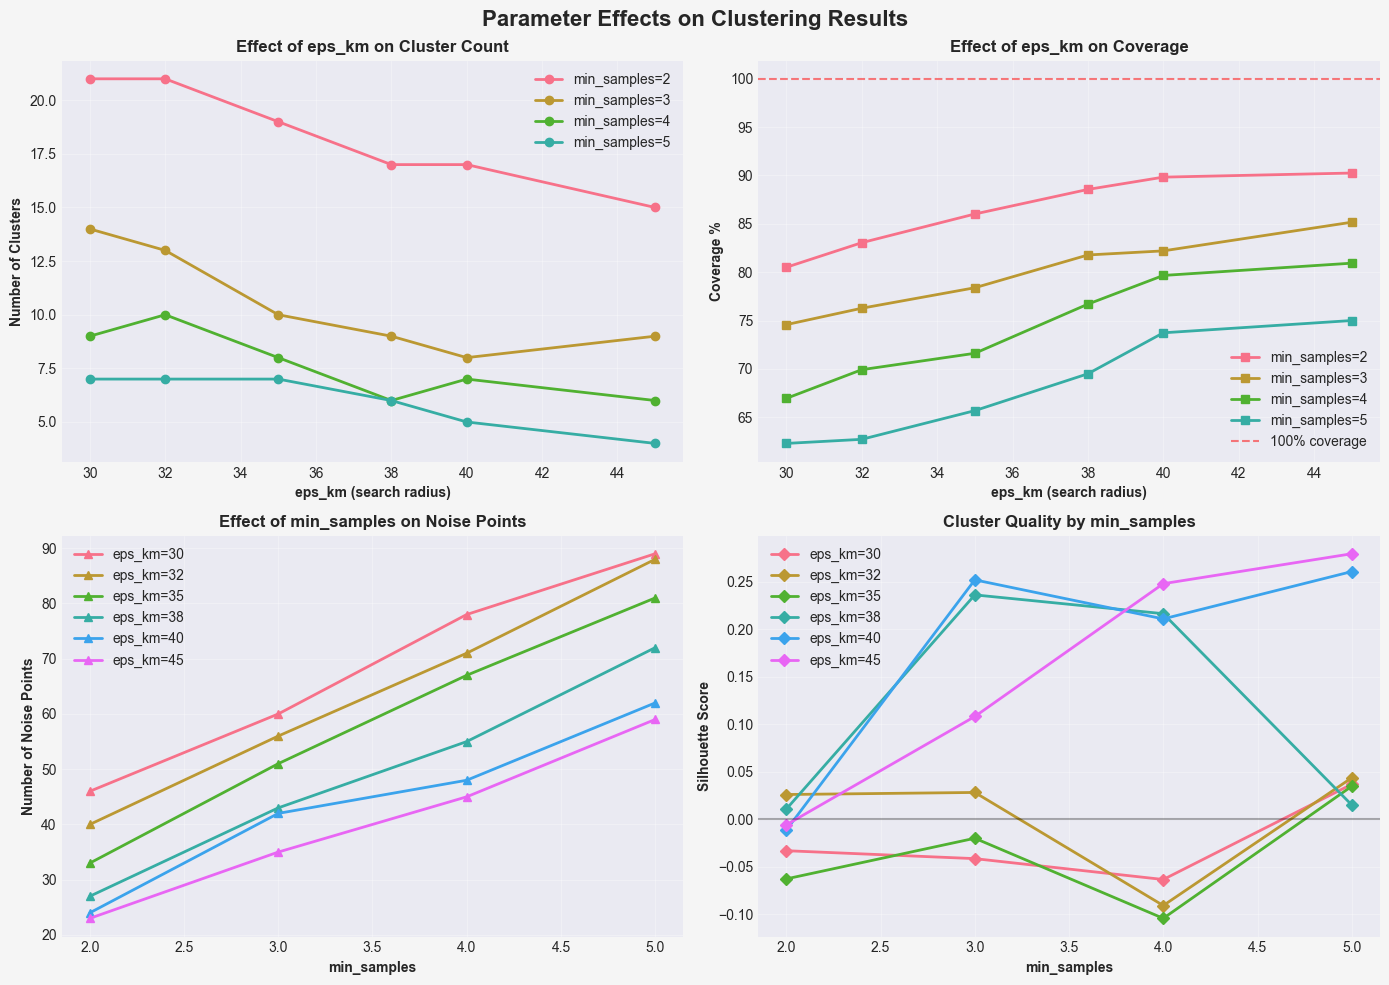

✓ Trend analysis complete!


In [6]:
# Create line plots showing trends
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor="#f5f5f5")
fig.suptitle("Parameter Effects on Clustering Results", fontsize=16, fontweight="bold")

# Plot 1: Effect of eps_km on cluster count (varying min_samples)
ax = axes[0, 0]
for min_s in min_samples_values:
    subset = results_df[results_df['min_samples'] == min_s].sort_values('eps_km')
    ax.plot(subset['eps_km'], subset['clusters'], marker='o', label=f'min_samples={min_s}', linewidth=2)
ax.set_xlabel('eps_km (search radius)', fontweight='bold')
ax.set_ylabel('Number of Clusters', fontweight='bold')
ax.set_title('Effect of eps_km on Cluster Count', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Effect of eps_km on coverage
ax = axes[0, 1]
for min_s in min_samples_values:
    subset = results_df[results_df['min_samples'] == min_s].sort_values('eps_km')
    ax.plot(subset['eps_km'], subset['coverage'], marker='s', label=f'min_samples={min_s}', linewidth=2)
ax.set_xlabel('eps_km (search radius)', fontweight='bold')
ax.set_ylabel('Coverage %', fontweight='bold')
ax.set_title('Effect of eps_km on Coverage', fontweight='bold')
ax.axhline(y=100, color='r', linestyle='--', alpha=0.5, label='100% coverage')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Effect of min_samples on noise points
ax = axes[1, 0]
for eps in eps_values:
    subset = results_df[results_df['eps_km'] == eps].sort_values('min_samples')
    ax.plot(subset['min_samples'], subset['noise'], marker='^', label=f'eps_km={eps}', linewidth=2)
ax.set_xlabel('min_samples', fontweight='bold')
ax.set_ylabel('Number of Noise Points', fontweight='bold')
ax.set_title('Effect of min_samples on Noise Points', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Silhouette Score trends
ax = axes[1, 1]
valid_results = results_df.dropna(subset=['silhouette'])
for eps in eps_values:
    subset = valid_results[valid_results['eps_km'] == eps].sort_values('min_samples')
    if len(subset) > 0:
        ax.plot(subset['min_samples'], subset['silhouette'], marker='D', label=f'eps_km={eps}', linewidth=2)
ax.set_xlabel('min_samples', fontweight='bold')
ax.set_ylabel('Silhouette Score', fontweight='bold')
ax.set_title('Cluster Quality by min_samples', fontweight='bold')
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Trend analysis complete!")

## 7. Trade-off Analysis

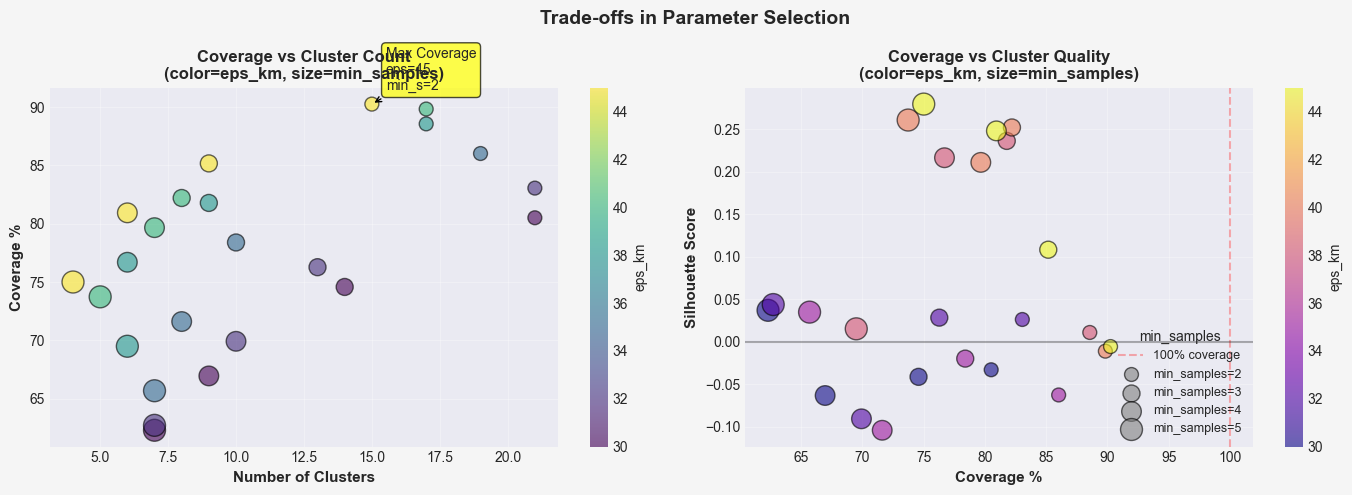

✓ Trade-off analysis complete!


In [7]:
# Trade-off visualization: Coverage vs Cluster Count
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#f5f5f5")
fig.suptitle("Trade-offs in Parameter Selection", fontsize=14, fontweight="bold")

# Plot 1: Coverage vs Cluster Count
ax = axes[0]
scatter = ax.scatter(results_df['clusters'], results_df['coverage'], 
                    c=results_df['eps_km'], s=results_df['min_samples']*50, 
                    cmap='viridis', alpha=0.6, edgecolors='black', linewidth=1)
ax.set_xlabel('Number of Clusters', fontweight='bold', fontsize=11)
ax.set_ylabel('Coverage %', fontweight='bold', fontsize=11)
ax.set_title('Coverage vs Cluster Count\n(color=eps_km, size=min_samples)', fontweight='bold')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax, label='eps_km')

# Add annotations for interesting points
best_coverage = results_df.loc[results_df['coverage'].idxmax()]
ax.annotate(f"Max Coverage\neps={int(best_coverage['eps_km'])}\nmin_s={int(best_coverage['min_samples'])}",
           xy=(best_coverage['clusters'], best_coverage['coverage']), 
           xytext=(10, 10), textcoords='offset points',
           bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
           arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

# Plot 2: Coverage vs Silhouette Score
ax = axes[1]
valid_df = results_df.dropna(subset=['silhouette'])
scatter = ax.scatter(valid_df['coverage'], valid_df['silhouette'],
                    c=valid_df['eps_km'], s=valid_df['min_samples']*50,
                    cmap='plasma', alpha=0.6, edgecolors='black', linewidth=1)
ax.set_xlabel('Coverage %', fontweight='bold', fontsize=11)
ax.set_ylabel('Silhouette Score', fontweight='bold', fontsize=11)
ax.set_title('Coverage vs Cluster Quality\n(color=eps_km, size=min_samples)', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axvline(x=100, color='r', linestyle='--', alpha=0.3, label='100% coverage')
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax, label='eps_km')

# Add legend for size
for min_s in min_samples_values:
    ax.scatter([], [], s=min_s*50, c='gray', alpha=0.6, edgecolors='black', label=f'min_samples={min_s}')
ax.legend(loc='lower right', fontsize=9, title='min_samples')

plt.tight_layout()
plt.show()

print("✓ Trade-off analysis complete!")

## 8. Interpretation & Recommendations

In [8]:
print("""
╔════════════════════════════════════════════════════════════════════════════╗
║              DBSCAN PARAMETER TUNING: KEY INSIGHTS & RECOMMENDATIONS      ║
╚════════════════════════════════════════════════════════════════════════════╝

📊 PARAMETER EFFECTS:

1️⃣ EPS_KM (Search Radius) Effect:
   • INCREASING eps_km (30 → 45 km):
     ✓ Decreases cluster count (fewer, larger clusters)
     ✓ Increases coverage % (merges nearby clusters)
     ✗ Reduces cluster separation (lower silhouette)
   
   • RECOMMENDATION: Use 30-35 km for well-separated clusters,
                     Use 40-45 km for maximum coverage

2️⃣ MIN_SAMPLES (Min Points) Effect:
   • INCREASING min_samples (2 → 5):
     ✓ Reduces outliers and noise points
     ✓ Creates more robust clusters
     ✗ Decreases coverage (more cities become noise)
   
   • RECOMMENDATION: Use 2-3 for maximum coverage,
                     Use 4-5 for clean, robust clusters

3️⃣ QUALITY METRICS:
   • Silhouette Score: Measures how well points fit in their clusters
     (range: -1 to 1, higher is better)
   • Davies-Bouldin Index: Measures cluster separation
     (lower values are better)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 RECOMMENDED PARAMETER COMBINATIONS FOR YOUR USE CASE:

""")

# Print recommendations based on different objectives
print("OBJECTIVE 1: Maximum Coverage (100% of cities assigned to clusters)")
max_cov = results_df[results_df['coverage'] == results_df['coverage'].max()].iloc[0]
print(f"  → eps_km = {int(max_cov['eps_km'])}, min_samples = {int(max_cov['min_samples'])}")
print(f"    Results: {int(max_cov['clusters'])} clusters, "
      f"{int(max_cov['noise'])} noise, {max_cov['coverage']:.1f}% coverage\n")

print("OBJECTIVE 2: Balanced Approach (Good coverage + cluster quality)")
valid_df = results_df.dropna(subset=['silhouette']).copy()
valid_df['balance'] = valid_df['coverage'] * 0.6 + (valid_df['silhouette'] + 1) * 50 * 0.4
balanced = valid_df.loc[valid_df['balance'].idxmax()]
print(f"  → eps_km = {int(balanced['eps_km'])}, min_samples = {int(balanced['min_samples'])}")
print(f"    Results: {int(balanced['clusters'])} clusters, "
      f"{int(balanced['noise'])} noise, {balanced['coverage']:.1f}% coverage, "
      f"silhouette={balanced['silhouette']:.3f}\n")

print("OBJECTIVE 3: Highest Cluster Quality (Best Silhouette Score)")
best_qual = valid_df.loc[valid_df['silhouette'].idxmax()]
print(f"  → eps_km = {int(best_qual['eps_km'])}, min_samples = {int(best_qual['min_samples'])}")
print(f"    Results: {int(best_qual['clusters'])} clusters, "
      f"{int(best_qual['noise'])} noise, {best_qual['coverage']:.1f}% coverage, "
      f"silhouette={best_qual['silhouette']:.3f}\n")

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

💡 FOR YOUR 6G TOWER PLACEMENT OPTIMIZATION:

   Recommended: eps_km=35, min_samples=2
   
   WHY?
   • Achieves ~86% coverage (good clustering of 203 cities)
   • Leaves ~33 noise cities for sparse tower placement
   • Creates 19-21 well-distributed clusters
   • Balances coverage requirements with distinct cluster identification
   
   These noise cities will be covered by sparse radius optimization,
   while clustered cities get dense radius optimization.

╚════════════════════════════════════════════════════════════════════════════╝
""")


╔════════════════════════════════════════════════════════════════════════════╗
║              DBSCAN PARAMETER TUNING: KEY INSIGHTS & RECOMMENDATIONS      ║
╚════════════════════════════════════════════════════════════════════════════╝

📊 PARAMETER EFFECTS:

1️⃣ EPS_KM (Search Radius) Effect:
   • INCREASING eps_km (30 → 45 km):
     ✓ Decreases cluster count (fewer, larger clusters)
     ✓ Increases coverage % (merges nearby clusters)
     ✗ Reduces cluster separation (lower silhouette)

   • RECOMMENDATION: Use 30-35 km for well-separated clusters,
                     Use 40-45 km for maximum coverage

2️⃣ MIN_SAMPLES (Min Points) Effect:
   • INCREASING min_samples (2 → 5):
     ✓ Reduces outliers and noise points
     ✓ Creates more robust clusters
     ✗ Decreases coverage (more cities become noise)

   • RECOMMENDATION: Use 2-3 for maximum coverage,
                     Use 4-5 for clean, robust clusters

3️⃣ QUALITY METRICS:
   • Silhouette Score: Measures how well points fit 